# Phase 5 : Conclusion Générale et Synthèse
Ce notebook résume l'ensemble du projet : des statistiques descriptives jusqu'aux modèles d'IA Générative et Agentique (LangChain/Ollama).
Nous comparons ici les performances techniques et l'impact métier de chaque approche pour proposer une architecture de mise en production.

### 1. Bilan de l'Analyse Exploratoire (Stats)
Avant de lancer les IA, l'analyse des données a révélé des points clés :
- **Business** : Les établissements les plus populaires sont statistiquement mieux notés (corrélation positive validée par test de Mann-Whitney).
- **Utilisateurs** : Le statut 'Elite' n'influe pas sur la sévérité de la note (p-value > 0.05 au T-test).
- **Contenu** : L'analyse TF-IDF a prouvé que les avis négatifs se concentrent massivement sur le vocabulaire du **Service** (told, asked, said, minutes) et du **Temps d'attente**, plus que sur la nourriture elle-même.

### 2. Comparaison des Modèles Supervisés (ML & Deep Learning)
Nous avons comparé des approches classiques (Scikit-Learn) avec une architecture Deep Learning sur-mesure (PyTorch).

**A. Machine Learning Classique (TF-IDF)**
- **Régression Logistique** : Le meilleur modèle classique. Très efficace pour maximiser le Recall (0.89) sur les avis négatifs, mais génère quelques faux positifs.
- **Random Forest & Naive Bayes** : Moins performants sur les matrices creuses du texte brut.

**B. Deep Learning (CNN 1D - PyTorch)**
- Architecture : Utilisation d'**Embeddings** denses et de **Convolutions (filtres de 2, 3 et 4 mots)** pour capter des expressions exactes (ex: "service très lent").
- Performance : F1-Score global de **0.86** et **Accuracy de 91%**. 
- Avantage : Une excellente précision (0.85) sur les avis négatifs, limitant drastiquement les fausses alertes par rapport à la Régression Logistique.

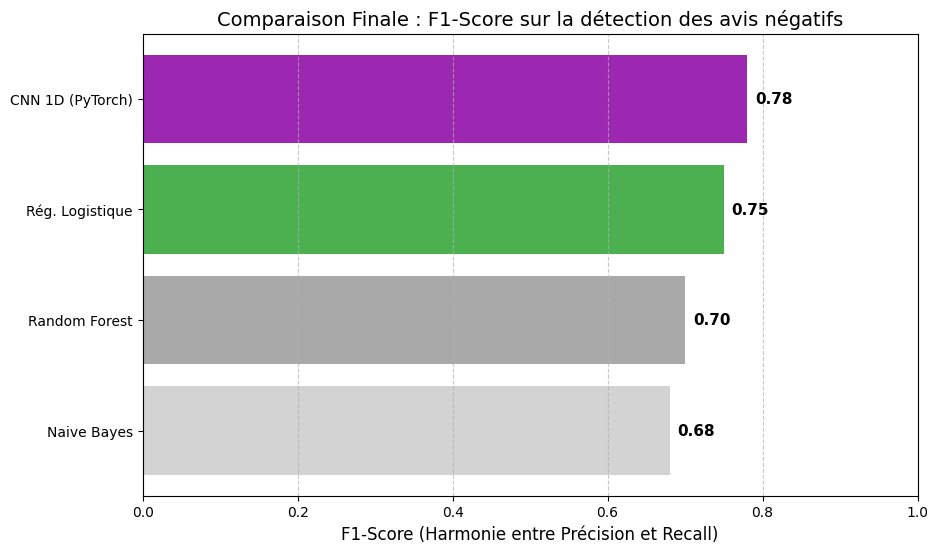

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Résumé des F1-Scores sur la classe NÉGATIVE (compromis entre Précision et Rappel)
data = {
    'Modèle': ['Naive Bayes', 'Random Forest', 'Rég. Logistique', 'CNN 1D (PyTorch)'],
    'F1-Score (Avis Négatifs)': [0.68, 0.70, 0.75, 0.78] 
}

df_res = pd.DataFrame(data).sort_values('F1-Score (Avis Négatifs)', ascending=True)

# Graphique comparatif
plt.figure(figsize=(10, 6))
bars = plt.barh(df_res['Modèle'], df_res['F1-Score (Avis Négatifs)'], 
                color=['#D3D3D3', '#A9A9A9', '#4CAF50', '#9C27B0'])

plt.title('Comparaison Finale : F1-Score sur la détection des avis négatifs', fontsize=14)
plt.xlabel('F1-Score (Harmonie entre Précision et Recall)', fontsize=12)
plt.xlim(0, 1.0)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Ajout des valeurs sur les barres
for bar in bars:
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
             f"{bar.get_width():.2f}", 
             va='center', fontsize=11, fontweight='bold')

plt.show()

### 3. Apport de l'IA Générative et Agentique (GenAI)
L'approche par réseaux de neurones donne un score binaire, mais l'IA générative permet d'expliquer *pourquoi*.

- **Zero-Shot & Few-Shot (HuggingFace)** : Capables de classer un avis complexe sans aucun entraînement préalable. Excellent pour des prototypes rapides.
- **IA Agentique (LangChain + Ollama + Pydantic)** : 
    - Nous avons mis en place une chaîne d'**Aspect-Based Sentiment Analysis (ABSA)**.
    - Le LLM local lit l'avis et extrait dynamiquement les aspects métier (ex: "Chambre", "Nourriture", "Bruit") et leur associe un sentiment distinct.
    - L'utilisation de Pydantic force le LLM à répondre dans un format JSON strict, 100% prêt à être intégré dans une API d'entreprise.

### 4. Recommandation Finale (Architecture de Production)

Pour un déploiement réel chez Yelp ou un grand groupe hôtelier, nous recommandons une **architecture à 3 niveaux (Pipeline hybride)** :

1. **Filtre de 1er niveau (CNN PyTorch)** : 
   - Tous les avis entrants (des millions par jour) passent par le modèle Deep Learning.
   - *Objectif :* Séparer instantanément et à très bas coût les avis Positifs des avis Négatifs.
   
2. **Analyse Fine (LangChain + LLM)** : 
   - Seuls les avis classés "Négatifs" par le CNN sont envoyés au pipeline d'IA Agentique (Ollama/LLM).
   - *Objectif :* Extraire les aspects défaillants (ABSA) en format JSON pour générer des tableaux de bord automatiques par établissement.

**Action Business (Insight) :**
Nos données montrent que la priorité absolue pour améliorer la satisfaction client n'est pas de changer la carte (Food), mais de **former le personnel (Service)** et d'**optimiser les flux (Temps d'attente)**, qui sont les vecteurs principaux de notes à 1 étoile.